***
# Delay-Based Level of Service (LOS) Analysis

This notebook evaluates the operational performance of the simulated corridor using delay-based Level of Service (LOS) indicators. The analysis is based on SUMO tripinfo output files generated for each representative scenario.

The purpose of this analysis is to complement the saturation-based evaluation. While the v/c ratio describes capacity utilization, delay-based LOS provides an additional indicator from the road user perspective.



In [18]:
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 1
# Define input/output paths + thesis plotting style
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre")
LOS_DIR = BASE_DIR / "LOS_Analysis"

LOS_DIR.mkdir(parents=True, exist_ok=True)

SCENARIOS = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

WARMUP_S = 900

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

print("LOS analysis directory:")
print(LOS_DIR)

LOS analysis directory:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LOS_Analysis


*****
## Step 2 — Read SUMO Tripinfo XML Files

In this step, the SUMO tripinfo XML files are read for all representative scenarios. Each tripinfo file contains vehicle-level simulation results such as departure time, arrival time, travel duration, route length, waiting time, and time loss.

The extracted data is stored in a single table so that all scenarios can be analyzed consistently in the following steps.

In [19]:
# ============================================================
# STEP 2
# Read SUMO tripinfo XML files
# ============================================================

rows = []

for scenario in SCENARIOS:
    tripinfo_file = LOS_DIR / f"tripinfo_{scenario}.xml"

    if not tripinfo_file.exists():
        print(f"Missing tripinfo file: {tripinfo_file}")
        continue

    tree = ET.parse(tripinfo_file)
    root = tree.getroot()

    for trip in root.findall("tripinfo"):
        rows.append({
            "scenario": scenario,
            "vehicle_id": trip.get("id"),
            "depart_s": float(trip.get("depart", 0)),
            "arrival_s": float(trip.get("arrival", 0)),
            "duration_s": float(trip.get("duration", 0)),
            "route_length_m": float(trip.get("routeLength", 0)),
            "waiting_time_s": float(trip.get("waitingTime", 0)),
            "time_loss_s": float(trip.get("timeLoss", 0)),
        })

trip_df = pd.DataFrame(rows)

if trip_df.empty:
    raise ValueError("No tripinfo data was found. Please check the XML files.")

print("Number of extracted vehicle trips:", len(trip_df))
display(trip_df.head())

Number of extracted vehicle trips: 12616


,scenario,vehicle_id,depart_s,arrival_s,duration_s,route_length_m,waiting_time_s,time_loss_s
0,weekday_morning,5,6.0,46.0,40.0,486.89,2.0,6.69
1,weekday_morning,26,31.0,49.0,18.0,139.77,0.0,4.90
2,weekday_morning,23,26.0,54.0,28.0,140.23,11.0,16.44
3,weekday_morning,43,46.0,58.0,12.0,139.77,0.0,0.29
4,weekday_morning,22,25.0,59.0,34.0,486.89,0.0,0.92


## Step 3 — Exclude Warm-up Period

In microscopic traffic simulation, the initial phase of the simulation is not representative of real traffic conditions. During this period, vehicles are still entering the network and traffic flow has not yet stabilized.

To ensure a consistent analysis, all vehicles that depart before the warm-up period of 900 seconds are excluded from the dataset. This step improves the reliability of the calculated delay and LOS indicators.

In [20]:
# ============================================================
# STEP 3
# Exclude warm-up period
# ============================================================

initial_count = len(trip_df)

# keep only vehicles that depart AFTER warm-up
trip_df = trip_df[trip_df["depart_s"] >= WARMUP_S].copy()

final_count = len(trip_df)

print(f"Vehicles before warm-up filtering: {initial_count}")
print(f"Vehicles after warm-up filtering: {final_count}")
print(f"Removed vehicles: {initial_count - final_count}")

display(trip_df.head())

Vehicles before warm-up filtering: 12616
Vehicles after warm-up filtering: 9936
Removed vehicles: 2680


,scenario,vehicle_id,depart_s,arrival_s,duration_s,route_length_m,waiting_time_s,time_loss_s
608,weekday_morning,759,905.0,918.0,13.0,128.17,0.0,0.76
629,weekday_morning,756,903.0,937.0,34.0,176.37,15.0,19.30
636,weekday_morning,762,907.0,941.0,34.0,156.75,15.0,23.11
637,weekday_morning,775,919.0,941.0,22.0,158.05,5.0,10.85
639,weekday_morning,781,925.0,942.0,17.0,158.05,0.0,4.90


## Step 4 — Classify Level of Service Based on Delay

In this step, the delay-based Level of Service (LOS) is classified for each vehicle. The main indicator used for the LOS classification is `timeLoss`, which represents the additional travel time caused by interactions with traffic, speed reductions, and waiting.

The LOS thresholds are based on typical delay-based categories for signalized intersections. Lower delay values indicate better traffic conditions, while higher delay values indicate increasing congestion and reduced operational performance.

In [21]:
# ============================================================
# STEP 4
# Classify Level of Service based on delay
# ============================================================

def classify_los(delay_s):
    if delay_s <= 10:
        return "A"
    elif delay_s <= 20:
        return "B"
    elif delay_s <= 35:
        return "C"
    elif delay_s <= 55:
        return "D"
    elif delay_s <= 80:
        return "E"
    else:
        return "F"


trip_df["los_time_loss"] = trip_df["time_loss_s"].apply(classify_los)
trip_df["los_waiting_time"] = trip_df["waiting_time_s"].apply(classify_los)

display(
    trip_df[
        [
            "scenario",
            "vehicle_id",
            "depart_s",
            "duration_s",
            "waiting_time_s",
            "time_loss_s",
            "los_time_loss",
            "los_waiting_time",
        ]
    ].head()
)

print("LOS distribution based on time loss:")
display(
    trip_df["los_time_loss"]
    .value_counts()
    .reindex(["A", "B", "C", "D", "E", "F"], fill_value=0)
    .reset_index()
    .rename(columns={"index": "LOS", "los_time_loss": "vehicle_count"})
)

,scenario,vehicle_id,depart_s,duration_s,waiting_time_s,time_loss_s,los_time_loss,los_waiting_time
608,weekday_morning,759,905.0,13.0,0.0,0.76,A,A
629,weekday_morning,756,903.0,34.0,15.0,19.30,B,B
636,weekday_morning,762,907.0,34.0,15.0,23.11,C,B
637,weekday_morning,775,919.0,22.0,5.0,10.85,B,A
639,weekday_morning,781,925.0,17.0,0.0,4.90,A,A


LOS distribution based on time loss:


,vehicle_count,count
0,A,1231
1,B,568
2,C,1018
3,D,1718
4,E,1490
5,F,3911


## Interpretation of Vehicle-Level LOS Distribution

The distribution of Level of Service (LOS) based on time loss shows that a significant share of vehicles experience high delay levels, particularly in the categories E and F. This indicates that the traffic system operates under congested conditions during the analyzed scenario.

Lower LOS classes (A and B), which represent free-flow or near free-flow conditions, are observed only for a smaller portion of vehicles. This suggests that only a limited number of vehicles are able to travel through the network without significant delay.

The high proportion of LOS D, E, and F reflects increased interaction between vehicles, longer waiting times at signalized intersections, and reduced operational efficiency of the network. These results are consistent with the saturation-based analysis, where several approaches exhibited high volume-to-capacity ratios.

Overall, the LOS distribution confirms that the network experiences considerable congestion during peak conditions, and that the simulation is able to capture this behavior at the vehicle level.

## Step 5 — Aggregate LOS Results by Scenario

In this step, the vehicle-level LOS results are aggregated at the scenario level. This provides a summary of traffic performance for each representative scenario and allows comparison between weekday and weekend conditions.

In [22]:
# ============================================================
# STEP 5
# Aggregate LOS by scenario
# ============================================================

los_summary = (
    trip_df
    .groupby(["scenario", "los_time_loss"])
    .size()
    .reset_index(name="vehicle_count")
)

# percentage hesapla
total_per_scenario = los_summary.groupby("scenario")["vehicle_count"].transform("sum")

los_summary["percentage"] = (
    los_summary["vehicle_count"] / total_per_scenario * 100
)

display(los_summary.head())

,scenario,los_time_loss,vehicle_count,percentage
0,weekday_evening,A,318,11.114995
1,weekday_evening,B,136,4.753583
2,weekday_evening,C,255,8.912967
3,weekday_evening,D,504,17.616218
4,weekday_evening,E,474,16.567634


## Step 6 — Visualization of LOS Distribution

The LOS distribution is visualized for each scenario to illustrate the proportion of vehicles in each service level category. This provides a clear comparison of traffic conditions across different time periods.

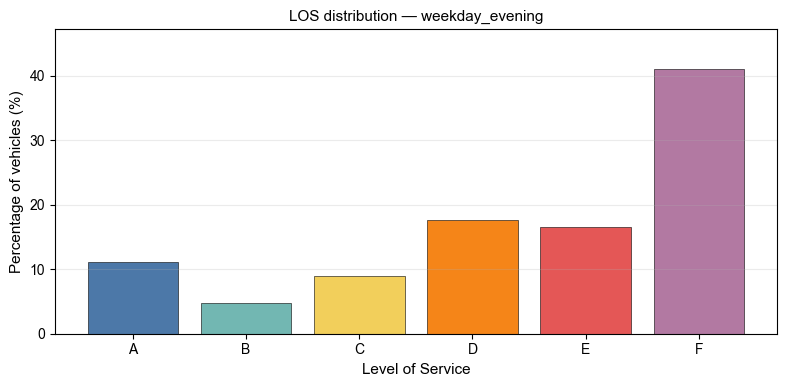

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LOS_Analysis\figures\los_distribution_weekday_evening.png


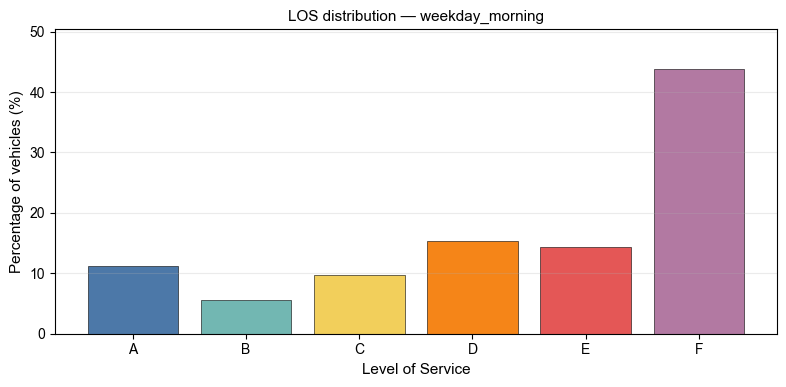

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LOS_Analysis\figures\los_distribution_weekday_morning.png


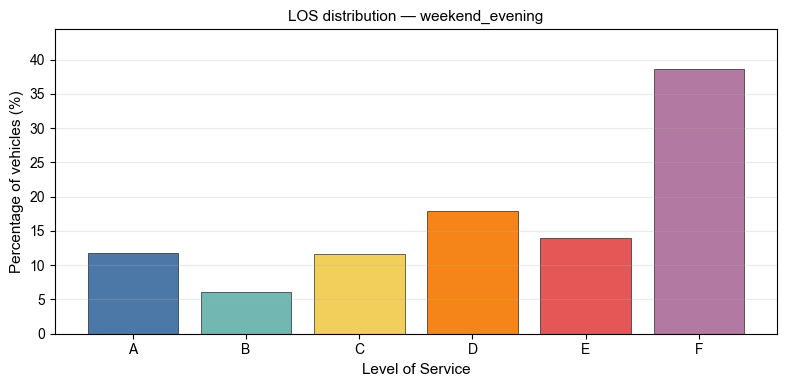

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LOS_Analysis\figures\los_distribution_weekend_evening.png


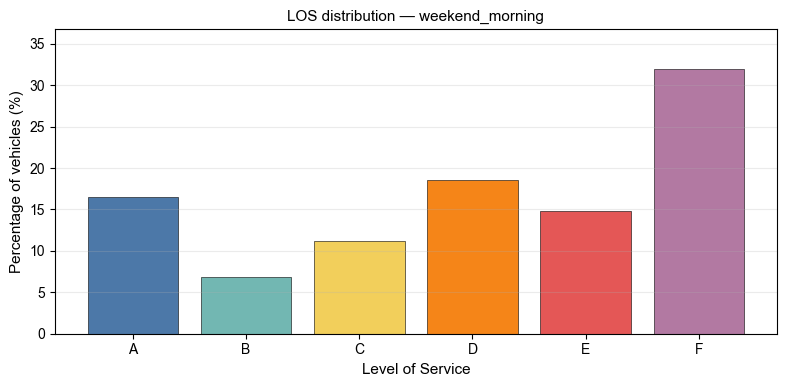

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LOS_Analysis\figures\los_distribution_weekend_morning.png


In [23]:
# ============================================================
# STEP 6
# Plot LOS distribution with LOS-specific colors
# ============================================================

FIG_DIR = LOS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

los_order = ["A", "B", "C", "D", "E", "F"]

los_colors = {
    "A": "#4C78A8",
    "B": "#72B7B2",
    "C": "#F2CF5B",
    "D": "#F58518",
    "E": "#E45756",
    "F": "#B279A2",
}

available_scenarios = los_summary["scenario"].unique()

for scenario in available_scenarios:

    temp = los_summary[los_summary["scenario"] == scenario].copy()

    temp = (
        temp.set_index("los_time_loss")
        .reindex(los_order)
        .fillna(0)
        .reset_index()
    )

    colors = temp["los_time_loss"].map(los_colors)

    plt.figure(figsize=(8, 4))

    plt.bar(
        temp["los_time_loss"],
        temp["percentage"],
        color=colors,
        edgecolor="black",
        linewidth=0.4,
    )

    plt.title(f"LOS distribution — {scenario}")
    plt.xlabel("Level of Service")
    plt.ylabel("Percentage of vehicles (%)")
    plt.ylim(0, max(temp["percentage"].max() * 1.15, 10))
    plt.grid(axis="y", alpha=0.25)

    plt.tight_layout()

    out_file = FIG_DIR / f"los_distribution_{scenario}.png"
    plt.savefig(out_file, dpi=300)
    plt.show()

    print("Saved:", out_file)

**The tripinfo-based LOS analysis was conducted at the scenario/corridor level because tripinfo outputs provide vehicle-level total delay indicators. For intersection-specific LOS evaluation, lane- or edge-based delay outputs are required.**

### Appendix Scenario-Level Average Delay

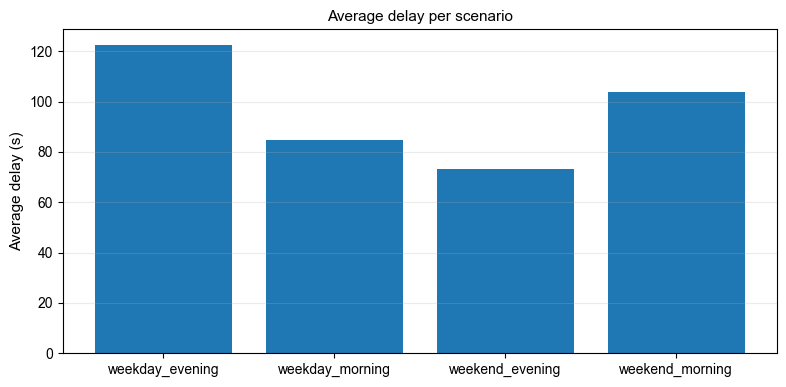

In [24]:
delay_summary = (
    trip_df
    .groupby("scenario", as_index=False)
    .agg(
        mean_delay=("time_loss_s", "mean"),
        median_delay=("time_loss_s", "median"),
        max_delay=("time_loss_s", "max"),
    )
)

plt.figure(figsize=(8,4))

plt.bar(
    delay_summary["scenario"],
    delay_summary["mean_delay"],
)

plt.ylabel("Average delay (s)")
plt.title("Average delay per scenario")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Appendix — Delay Distribution

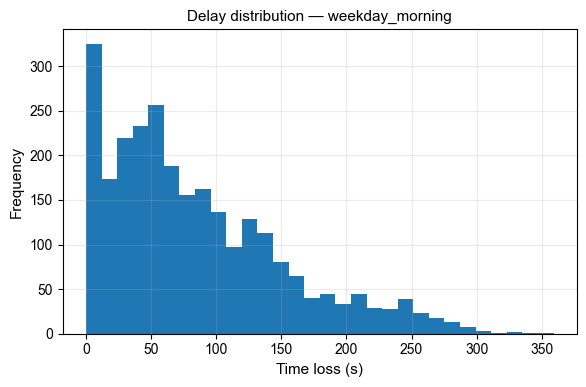

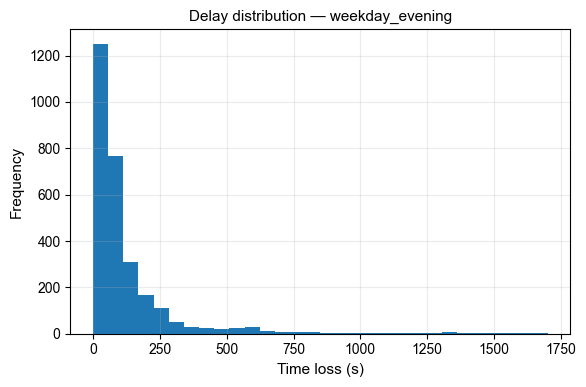

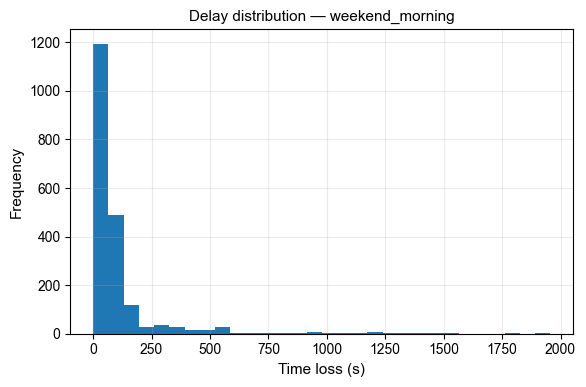

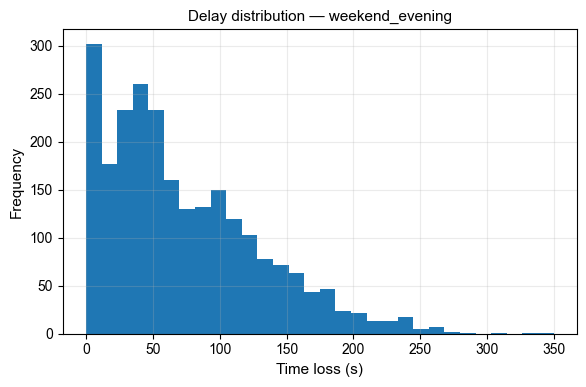

In [25]:
for scenario in trip_df["scenario"].unique():

    temp = trip_df[trip_df["scenario"] == scenario]

    plt.figure(figsize=(6,4))

    plt.hist(
        temp["time_loss_s"],
        bins=30,
    )

    plt.title(f"Delay distribution — {scenario}")
    plt.xlabel("Time loss (s)")
    plt.ylabel("Frequency")

    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

### The consistency between saturation levels (v/c ratio) and delay-based LOS results confirms that the simulation model is internally coherent and capable of capturing both capacity utilization and user-perceived performance.

## Several limitations should be considered. The signal control was represented using static programs derived from observed data, while real-world signal control is typically actuated. In addition, tripinfo-based LOS was evaluated at the corridor level, as intersection-specific delay attribution is not directly available. Detector data quality and mapping assumptions may also introduce uncertainty.